In [1]:
import torch
import matplotlib.pyplot as plt

from src.models.baseline_model import BaselineModel
from src.data.roadgraph_dm import RoadGraphDataModule
from src.data.graph_utils import build_knn_from_pred, convert_edges_to_local, detect_nodes, build_knn_feature_space, assign_pred_to_gt

device = "cpu"

/users/kmaeda2/.conda/envs/csci2952_mocov3/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load model weight

In [2]:
ckpt_path = "checkpoints_stage2/last.ckpt"

model = BaselineModel.load_from_checkpoint(
    "checkpoints_stage2/last.ckpt",
    warmup_epochs=10,
    anneal_epochs=20,
    min_gt_prob=0.2,
    lr=1e-3,
    weight_decay=1e-5
)

model.to(device)
model.eval()

BaselineModel(
  (backboneEncoder): BackBoneEncoder(
    (backbone): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(i

## Get one instance from the dataset

In [ ]:
dm = RoadGraphDataModule(
    root="/oscar/home/kmaeda2/RoadGraphPlus",
    batch_size=32,
    max_items=150
)
dm.setup("test")

test_loader = dm.test_dataloader()
it = iter(test_loader)
batch = next(it)
batch["image"] = batch["image"].to(device)

b = 0

image = batch["image"][b:b+1]
nodes_xy_gt = batch["nodes"][b]
gt_edges_global = batch["edges"][b]
node_ids_global = batch["node_ids"][b]

gt_edges_local = convert_edges_to_local(node_ids_global, gt_edges_global)

train files 120
val files 15
test files 15


## Get nodes predictions

In [4]:
with torch.no_grad():
    o_pred, j_pred, n_map = model(image)

HI,WI = image.shape[-2:]  
Hc, Wc = n_map.shape[-2:]

with torch.no_grad():
    nodes_xy_pred, scores, cells_ij = detect_nodes(
        j_pred, o_pred, HI, WI, threshold=0.4
)
nodes_xy_pred.shape, scores.shape

(torch.Size([16, 2]), torch.Size([16]))

In [5]:
px = nodes_xy_pred[:,0]
py = nodes_xy_pred[:,1]

Xc = torch.clamp((px / WI * Wc).floor().long(), 0, Wc-1)
Yc = torch.clamp((py / HI * Hc).floor().long(), 0, Hc-1)

node_feats = n_map[b][:, Yc, Xc].permute(1,0)
node_feats.shape


torch.Size([16, 256])

## Build a edge graph

In [6]:
edge_index = build_knn_feature_space(node_feats, k=8) 
edge_index.shape

torch.Size([2, 128])

In [7]:
min_idx = assign_pred_to_gt(nodes_xy_pred, nodes_xy_gt, max_dist=48)
valid_edge_mask = (min_idx[edge_index[0]] >= 0) & (min_idx[edge_index[1]] >= 0)
edge_index = edge_index[:, valid_edge_mask]

## Run GNN

In [8]:
node_emb, eidx, edge_logits = model.roadGraphGNN(
    node_feats,
    nodes_xy_pred,
    edge_index
)

In [9]:
pred_edge_mask = edge_logits.sigmoid() > 0.5

edge_index_pred = edge_index[:, pred_edge_mask]
edge_index_pred.shape

torch.Size([2, 1])

In [14]:
import numpy as np

def tensor_image_to_numpy(img_tensor):
    if img_tensor.dim() == 4:
        img_tensor = img_tensor[0]
    img = img_tensor.detach().cpu()
    if img.shape[0] == 3:
        img = img.permute(1, 2, 0)  # (H,W,3)
    else:
        raise ValueError("Unexpected channel shape")

    img = img.float()
    img = img.clamp(0, 1)
    img = (img * 255).byte().numpy()
    return img

def draw_graph(ax, img, nodes_xy, edges, node_color="red", edge_color="red", title=None):
    ax.imshow(img, origin="upper")
    ax.axis("off")
    if title is not None:
        ax.set_title(title)

    if isinstance(nodes_xy, torch.Tensor):
        nodes_xy_np = nodes_xy.detach().cpu().numpy()
    else:
        nodes_xy_np = np.asarray(nodes_xy)

    if isinstance(edges, torch.Tensor):
        edges_np = edges.detach().cpu().numpy()
    else:
        edges_np = np.asarray(edges)

    # draw nodes
    ax.scatter(nodes_xy_np[:, 0], nodes_xy_np[:, 1],
               s=10, c=node_color, alpha=0.8)

    # draw edges
    for i, j in edges_np:
        x1, y1 = nodes_xy_np[i]
        x2, y2 = nodes_xy_np[j]
        ax.plot([x1, x2], [y1, y2], color=edge_color, linewidth=5, alpha=0.7)


In [15]:
img_np = tensor_image_to_numpy(image[0])  # (H,W,3)

# GT graph
gt_edges_for_plot = gt_edges_local 

# Predicted graph
pred_edges_for_plot = edge_index_pred.t()  # (E_pred,2)

In [16]:
H, W = img_np.shape[:2]

def flip_y(nodes_xy, H):
    if isinstance(nodes_xy, torch.Tensor):
        nodes = nodes_xy.detach().clone()
    else:
        nodes = torch.from_numpy(np.asarray(nodes_xy)).clone()
    nodes[:, 1] = H - 1 - nodes[:, 1]   # y -> H-1-y
    return nodes

nodes_gt_vis   = flip_y(nodes_xy_gt,   H)
nodes_pred_vis = flip_y(nodes_xy_pred, H)


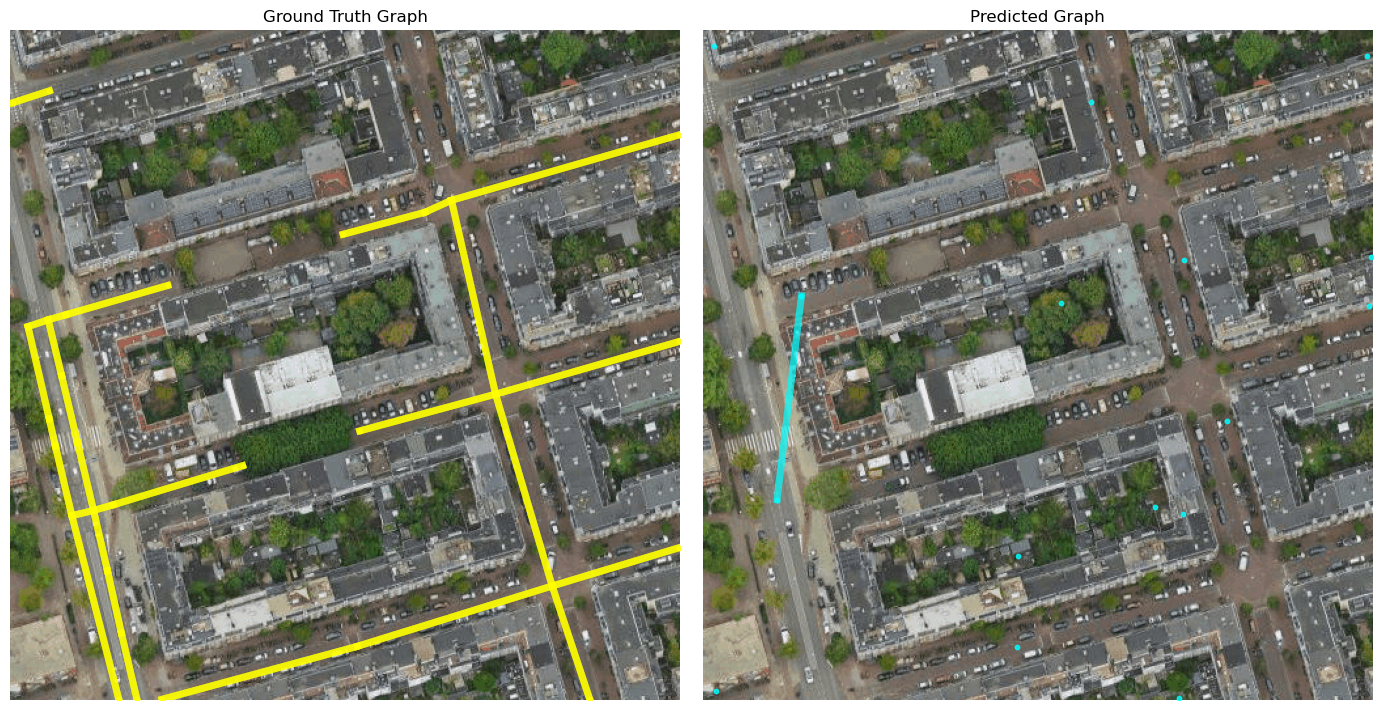

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))


draw_graph(
    axes[0],
    img_np,
    nodes_gt_vis,
    gt_edges_for_plot,
    node_color="yellow",
    edge_color="yellow",
    title="Ground Truth Graph",
)

draw_graph(
    axes[1],
    img_np,
    nodes_pred_vis,
    pred_edges_for_plot,
    node_color="cyan",
    edge_color="cyan",
    title="Predicted Graph",
)

plt.tight_layout()
plt.show()